In [2]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss, silhouette_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, normalize
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


In [3]:
notebook_dir

WindowsPath('C:/Users/USER/Documents/GitHub/psychic-spoon/0 Meeting')

Text(0.5, 1.0, 'Weekly samples & defect ratio')

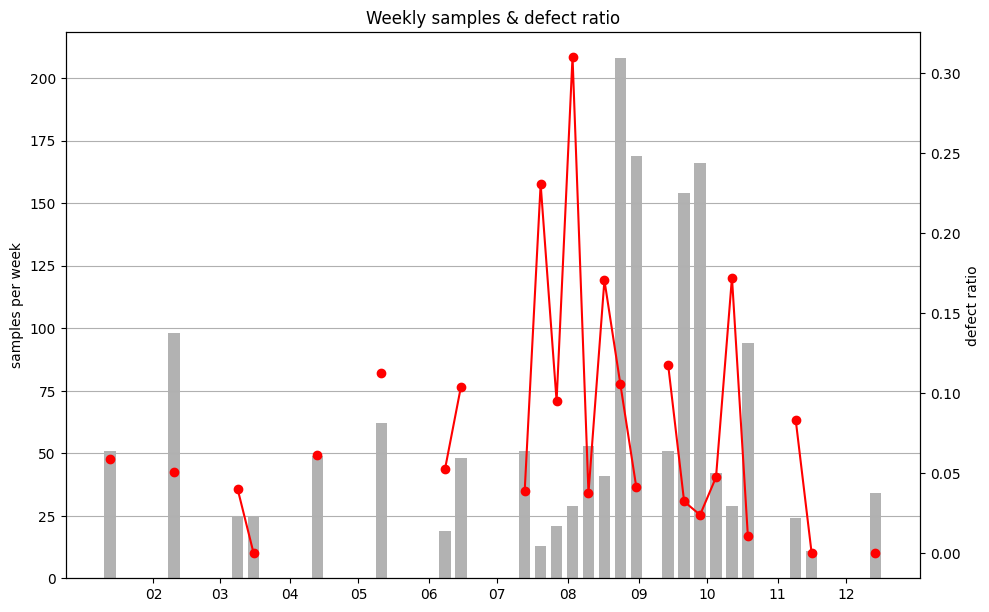

In [4]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


x447: mean=1.175, std=0.176, 3σ區間=(0.647, 1.703)


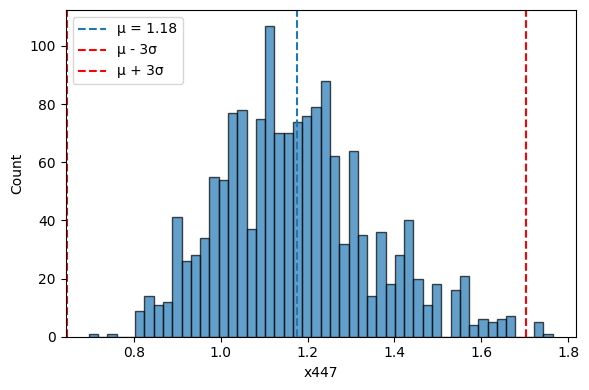

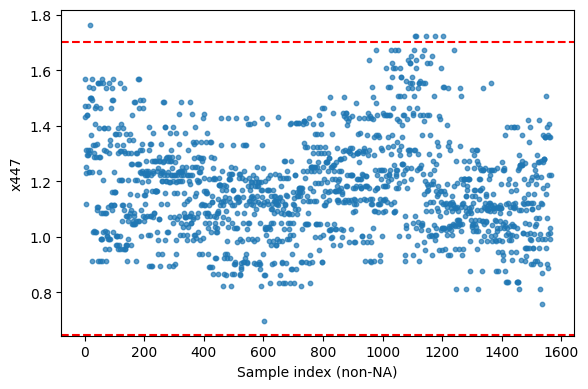

In [5]:
# 指定要用的特徵名稱
col = "x447"   # 若實際欄位叫 "X1" 就改成 "X1"

# 取出 X1，先丟掉缺失
x1 = secom[col].dropna()

# 計算平均與標準差
mu = x1.mean()
sigma = x1.std()

# 3-sigma 門檻
lower = mu - 3 * sigma
upper = mu + 3 * sigma

print(f"{col}: mean={mu:.3f}, std={sigma:.3f}, 3σ區間=({lower:.3f}, {upper:.3f})")

# 1) 直方圖 + 3-sigma 線
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(x1, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(mu, linestyle="--", linewidth=1.5, label=f"μ = {mu:.2f}")
ax.axvline(lower, color="red", linestyle="--", linewidth=1.5, label="μ - 3σ")
ax.axvline(upper, color="red", linestyle="--", linewidth=1.5, label="μ + 3σ")
ax.set_xlabel(col)
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

# 2) 依樣本順序的散佈圖 + 3-sigma 線（看 outlier 位置）
idx = np.arange(len(x1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(idx, x1.values, s=10, alpha=0.7)
ax.axhline(lower, color="red", linestyle="--", linewidth=1.5)
ax.axhline(upper, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Sample index (non-NA)")
ax.set_ylabel(col)
plt.tight_layout()
plt.show()

#### PCA + Kmeans, 2 clusters

PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


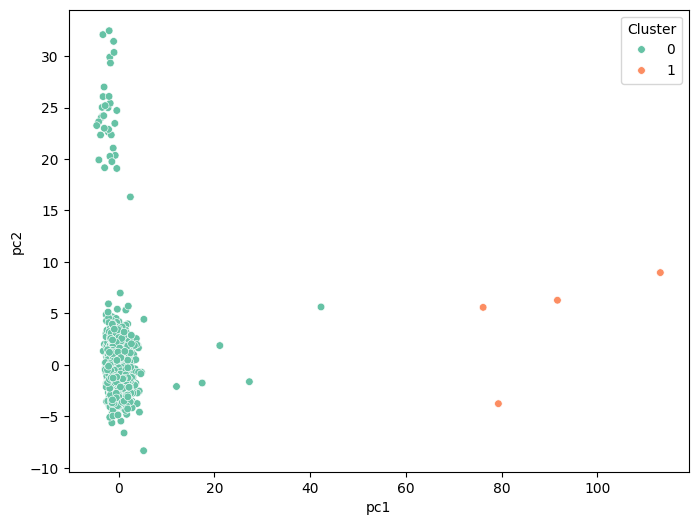

In [6]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

#### StandardScaler + Kmeans + elbow, 4 cluster

Elbow 法推測的最佳 K = 4


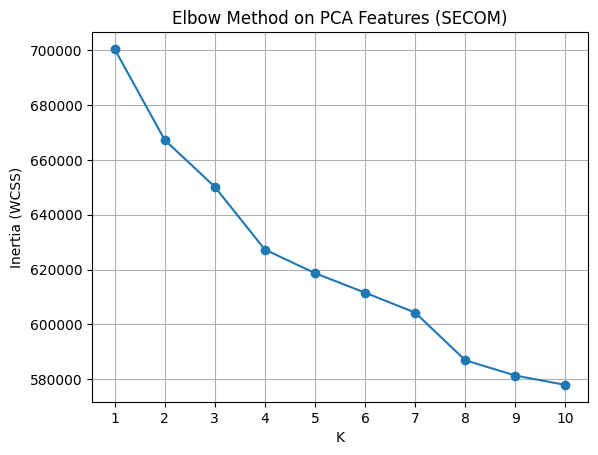

cluster sizes: {0: 32, 1: 722, 2: 4, 3: 809}
cluster   0    1  2    3
y                       
0        25  667  3  768
1         7   55  1   41
PCA 保留 131 個主成分


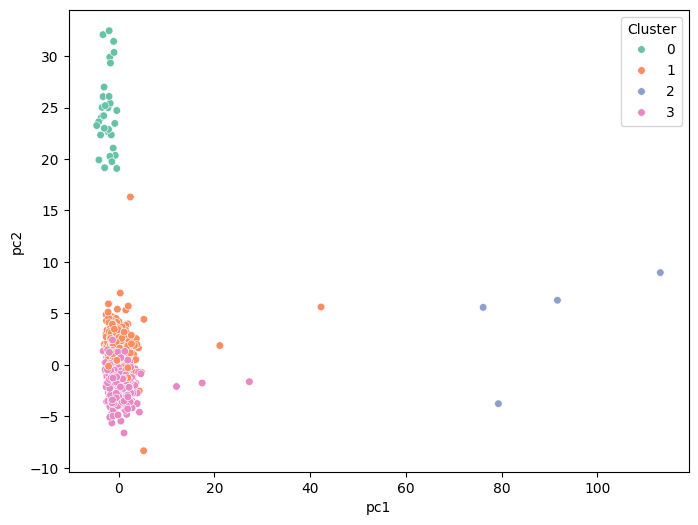

In [7]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

Ks = list(range(1, 11))  # 可自行調整上限，例如到 15 或 20
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_std)
    inertias.append(km.inertia_)  # WCSS

# 找 elbow（幾何法：點到首尾連線的最大距離）
def find_elbow(Ks, inertias):
    x = np.array(Ks, dtype=float)
    y = np.array(inertias, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    # 各點到線段 p1-p2 的距離
    pts = np.column_stack([x, y])
    distances = np.abs(np.cross(p2 - p1, pts - p1)) / np.linalg.norm(p2 - p1)
    return int(x[np.argmax(distances)])

elbow_k = find_elbow(Ks, inertias)
print(f"Elbow 法推測的最佳 K = {elbow_k}")

# 繪圖
plt.figure()
plt.plot(Ks, inertias, marker='o')
plt.xticks(Ks)
plt.xlabel('K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method on PCA Features (SECOM)')
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=elbow_k, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_std)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])
X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

#### PCA + Kmeans + elbow, 6 cluster

PCA 保留 131 個主成分
Elbow 法推測的最佳 K = 6


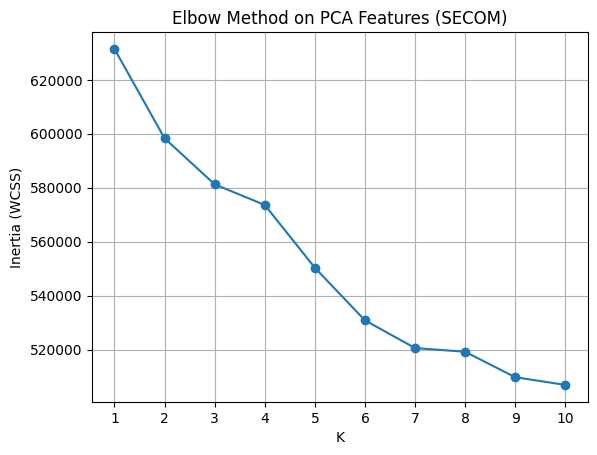

cluster sizes: {0: 32, 1: 599, 2: 679, 3: 4, 4: 1, 5: 252}
cluster   0    1    2  3  4    5
y                               
0        25  563  627  3  1  244
1         7   36   52  1  0    8


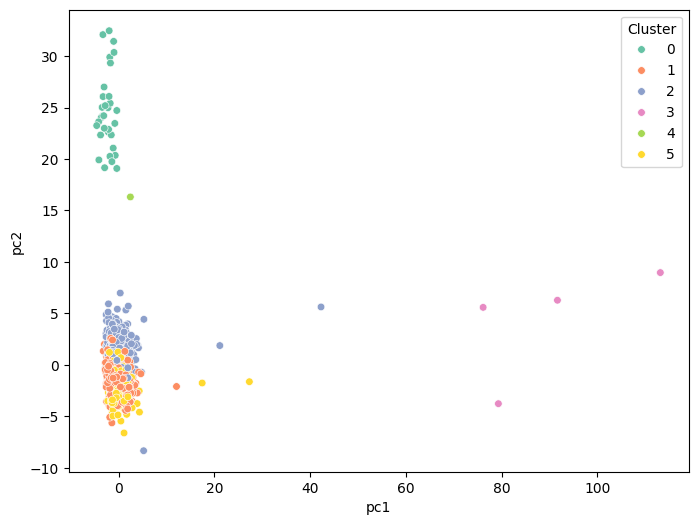

In [8]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

Ks = list(range(1, 11))  # 可自行調整上限，例如到 15 或 20
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_pca_df)
    inertias.append(km.inertia_)  # WCSS

# 找 elbow（幾何法：點到首尾連線的最大距離）
def find_elbow(Ks, inertias):
    x = np.array(Ks, dtype=float)
    y = np.array(inertias, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    # 各點到線段 p1-p2 的距離
    pts = np.column_stack([x, y])
    distances = np.abs(np.cross(p2 - p1, pts - p1)) / np.linalg.norm(p2 - p1)
    return int(x[np.argmax(distances)])

elbow_k = find_elbow(Ks, inertias)
print(f"Elbow 法推測的最佳 K = {elbow_k}")

# 繪圖
plt.figure()
plt.plot(Ks, inertias, marker='o')
plt.xticks(Ks)
plt.xlabel('K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method on PCA Features (SECOM)')
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=elbow_k, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

#### 有pca, 沒有oversampling

In [9]:
mask = (labels == 3)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

#### 用X_pca做重複事情

In [ ]:
mask = (labels == 1)
X_sub = X_pca_df.drop(columns=['Cluster']).loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[111  23]
 [  7   4]]

SVM(RBF) confusion matrix:
[[134   0]
 [ 11   0]]

DecisionTree confusion matrix:
[[123  11]
 [  9   2]]

RandomForest confusion matrix:
[[134   0]
 [ 11   0]]

XGBoost confusion matrix:
[[134   0]
 [ 11   0]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.7931  0.1716       0.3636       0.8284  0.5488
SVM(RBF)            0.9241  0.0000       0.0000       1.0000  0.0000
DecisionTree        0.8621  0.0821       0.1818       0.9179  0.4085
RandomForest        0.9241  0.0000       0.0000       1.0000  0.0000
XGBoost             0.9241  0.0000       0.0000       1.0000  0.0000


#### 有pca, oversampling

In [ ]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[258  30]
 [ 15   4]]

SVM(RBF) confusion matrix:
[[288   0]
 [ 19   0]]

DecisionTree confusion matrix:
[[260  28]
 [ 15   4]]

RandomForest confusion matrix:
[[287   1]
 [ 18   1]]

XGBoost confusion matrix:
[[286   2]
 [ 17   2]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8534  0.1042       0.2105       0.8958  0.4343
SVM(RBF)            0.9381  0.0000       0.0000       1.0000  0.0000
DecisionTree        0.8599  0.0972       0.2105       0.9028  0.4360
RandomForest        0.9381  0.0035       0.0526       0.9965  0.2290
XGBoost             0.9381  0.0069       0.1053       0.9931  0.3233


In [ ]:
# DecisionTree 混淆矩陣
dtree = models["DecisionTree"]
yhat_dt = predict_labels(dtree, Xte)

cm = confusion_matrix(yte, yhat_dt, labels=[0,1])
TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"\nDecisionTree confusion matrix:\n{cm}")

# 建立 mask
mask_tn = (yte==0) & (yhat_dt==0)
mask_fp = (yte==0) & (yhat_dt==1)

# 各類樣本數
print(f"TN={mask_tn.sum()}, FP={mask_fp.sum()}")

Xte_df = pd.DataFrame(Xte, columns=X.columns)
# 計算每個特徵的平均差異與 p-value
diffs = []
for col in Xte_df.columns:
    group_tn = Xte_df.loc[mask_tn, col]
    group_fp = Xte_df.loc[mask_fp, col]
    stat, p = ttest_ind(group_fp, group_tn, equal_var=False, nan_policy='omit')
    mean_diff = group_fp.mean() - group_tn.mean()
    diffs.append((col, mean_diff, p))

# 排序後輸出前 20 名
df_diff = pd.DataFrame(diffs, columns=['feature', 'mean_diff', 'p_value'])
df_diff['abs_diff'] = df_diff['mean_diff'].abs()
df_diff = df_diff.sort_values('p_value', ascending=True).head(20)
print("\np-value小到大排序")
print(df_diff.round(4))


DecisionTree confusion matrix:
[[266  22]
 [ 18   1]]
TN=266, FP=22


c:\Users\USER\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



p-value小到大排序
    feature  mean_diff  p_value  abs_diff
332    x434    -0.5628   0.0001    0.5628
357    x469    -0.5855   0.0006    0.5855
315    x416    -0.2906   0.0006    0.2906
129    x143    -0.2987   0.0009    0.2987
222    x280    -0.3606   0.0010    0.3606
240    x301    -0.1173   0.0010    0.1173
131    x145    -0.3512   0.0013    0.3512
317    x418    -0.3701   0.0013    0.3701
149    x166    -0.1335   0.0019    0.1335
335    x437    -0.0207   0.0022    0.0207
268    x339    -0.1205   0.0049    0.1205
256    x320     0.5693   0.0056    0.5693
11      x13    -0.3365   0.0059    0.3365
218    x275    -0.3608   0.0059    0.3608
127    x140    -0.3771   0.0060    0.3771
177    x203    -0.1598   0.0062    0.1598
16      x19    -0.4251   0.0064    0.4251
351    x456     0.5745   0.0078    0.5745
54      x60     0.6586   0.0089    0.6586
165    x184     0.5633   0.0096    0.5633


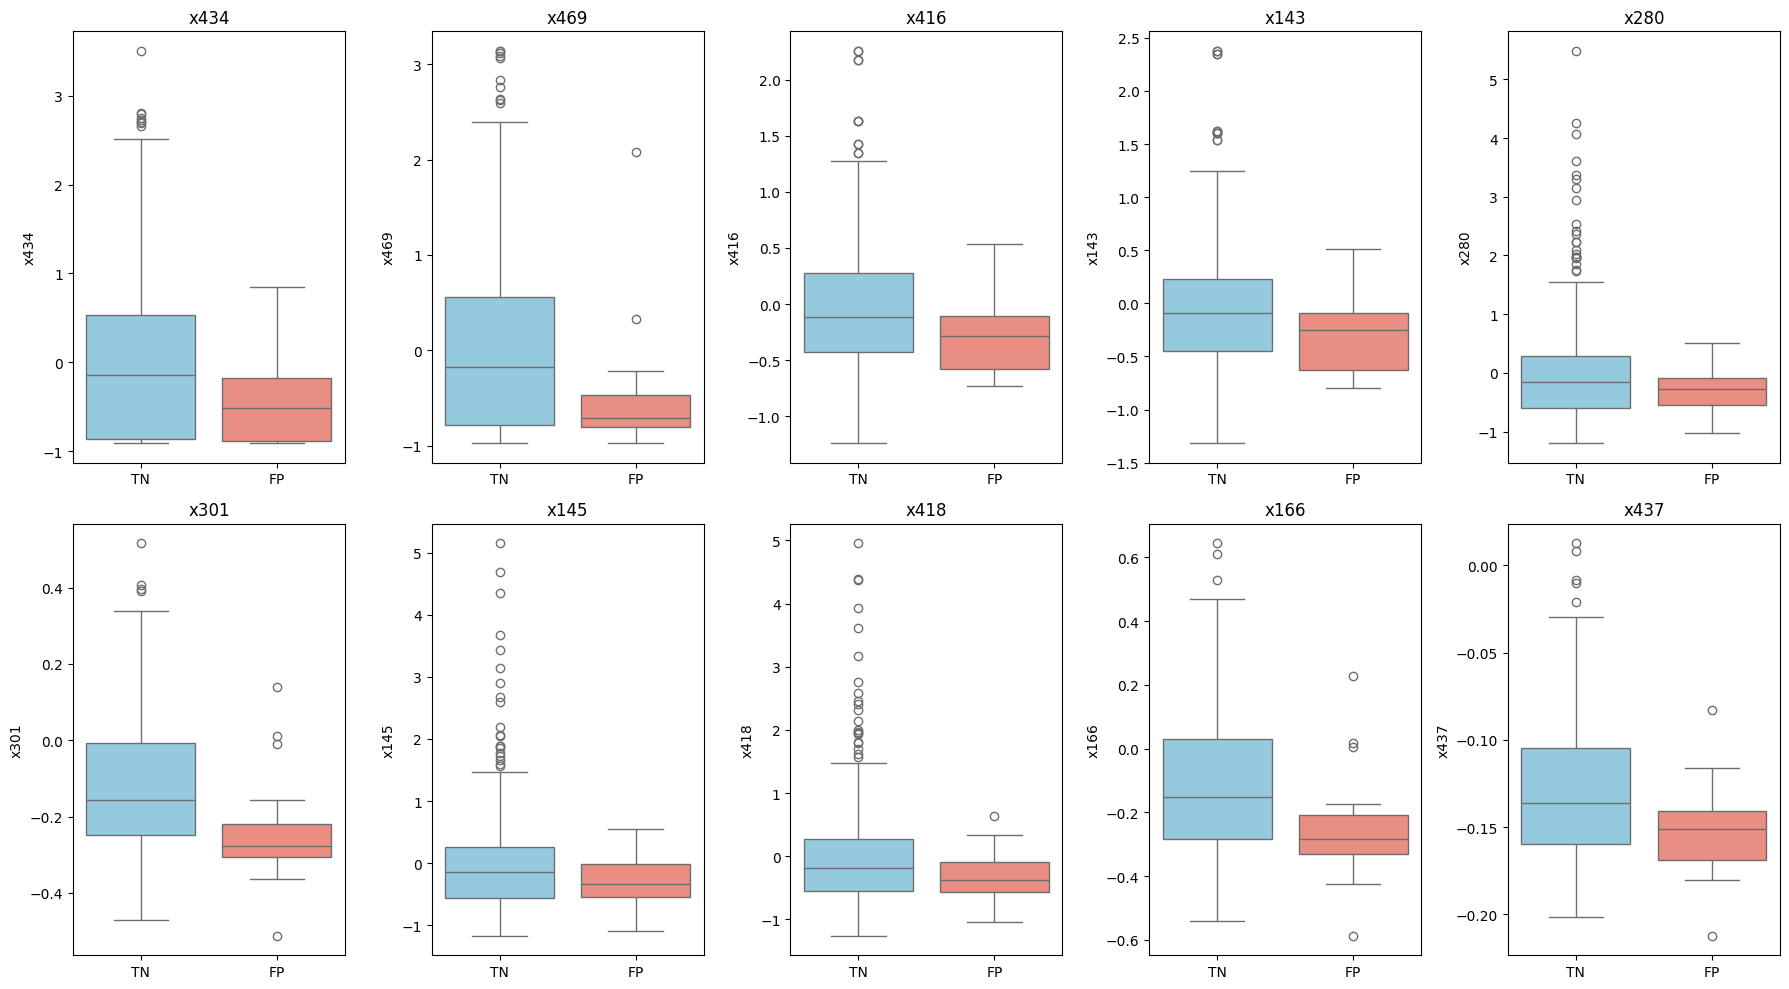

In [ ]:

features = ["x434","x469","x416","x143","x280",
            "x301","x145","x418","x166","x437"]

plt.figure(figsize=(18, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(data=Xte_df.loc[mask_tn, [col]].assign(group='TN'),
                x='group', y=col, color='skyblue')
    sns.boxplot(data=Xte_df.loc[mask_fp, [col]].assign(group='FP'),
                x='group', y=col, color='salmon')
    plt.title(col)
    plt.xlabel("")
    plt.tight_layout()

plt.show()

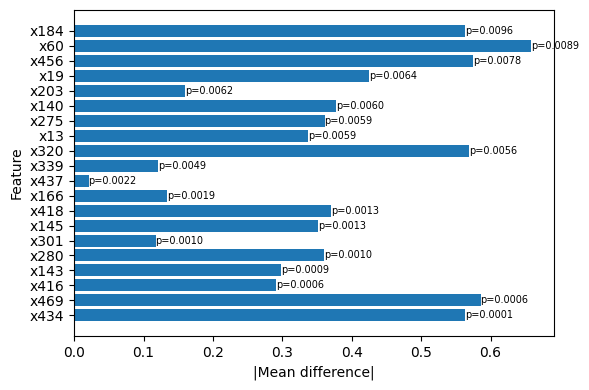

In [ ]:
df_sorted = df_diff.sort_values("p_value")  # p-value 由小到大

plt.figure(figsize=(6,4))
plt.barh(df_sorted["feature"], df_sorted["mean_diff"].abs())
for i, (xv, pv) in enumerate(zip(df_sorted["mean_diff"].abs(),
                                 df_sorted["p_value"])):
    plt.text(xv, i, f"p={pv:.4f}", va="center", ha="left", fontsize=7)

plt.xlabel("|Mean difference|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


#### 用X_pca做重複事情

In [ ]:
mask = (labels == 0)
X_sub = X_pca_df.drop(columns=['Cluster']).loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))

#### 原始資料, 沒有pca, 有oversampling

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

Xtr, Xte, ytr, yte = train_test_split(X_std, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[262  31]
 [ 17   4]]

SVM(RBF) confusion matrix:
[[293   0]
 [ 21   0]]

DecisionTree confusion matrix:
[[247  46]
 [ 18   3]]

RandomForest confusion matrix:
[[293   0]
 [ 21   0]]

XGBoost confusion matrix:
[[292   1]
 [ 21   0]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8471  0.1058       0.1905       0.8942  0.4127
SVM(RBF)            0.9331  0.0000       0.0000       1.0000  0.0000
DecisionTree        0.7962  0.1570       0.1429       0.8430  0.3470
RandomForest        0.9331  0.0000       0.0000       1.0000  0.0000
XGBoost             0.9299  0.0034       0.0000       0.9966  0.0000


#### 有pca, oversampling, 5-folds cv

In [ ]:
mask = (labels == 2)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, GM={met['GM']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.801, FAR=0.167, GM=0.577
Fold 2: acc=0.882, FAR=0.071, GM=0.528
Fold 3: acc=0.757, FAR=0.184, GM=0.272
Fold 4: acc=0.831, FAR=0.104, GM=0.285
Fold 5: acc=0.822, FAR=0.136, GM=0.509

=== SVM(RBF) ===
Fold 1: acc=0.926, FAR=0.000, GM=0.000
Fold 2: acc=0.926, FAR=0.000, GM=0.000
Fold 3: acc=0.919, FAR=0.000, GM=0.000
Fold 4: acc=0.919, FAR=0.000, GM=0.000
Fold 5: acc=0.926, FAR=0.000, GM=0.000

=== DecisionTree ===
Fold 1: acc=0.846, FAR=0.119, GM=0.594
Fold 2: acc=0.838, FAR=0.127, GM=0.591
Fold 3: acc=0.801, FAR=0.152, GM=0.481
Fold 4: acc=0.831, FAR=0.104, GM=0.285
Fold 5: acc=0.859, FAR=0.112, GM=0.666

=== RandomForest ===
Fold 1: acc=0.912, FAR=0.016, GM=0.000
Fold 2: acc=0.926, FAR=0.000, GM=0.000
Fold 3: acc=0.926, FAR=0.000, GM=0.302
Fold 4: acc=0.919, FAR=0.000, GM=0.000
Fold 5: acc=0.919, FAR=0.008, GM=0.000

=== XGBoost ===
Fold 1: acc=0.912, FAR=0.024, GM=0.312
Fold 2: acc=0.926, FAR=0.008, GM=0.315
Fold 3: acc=0.919, FAR=0.016, GM=0.

---
---

#### 階層式凝聚分群

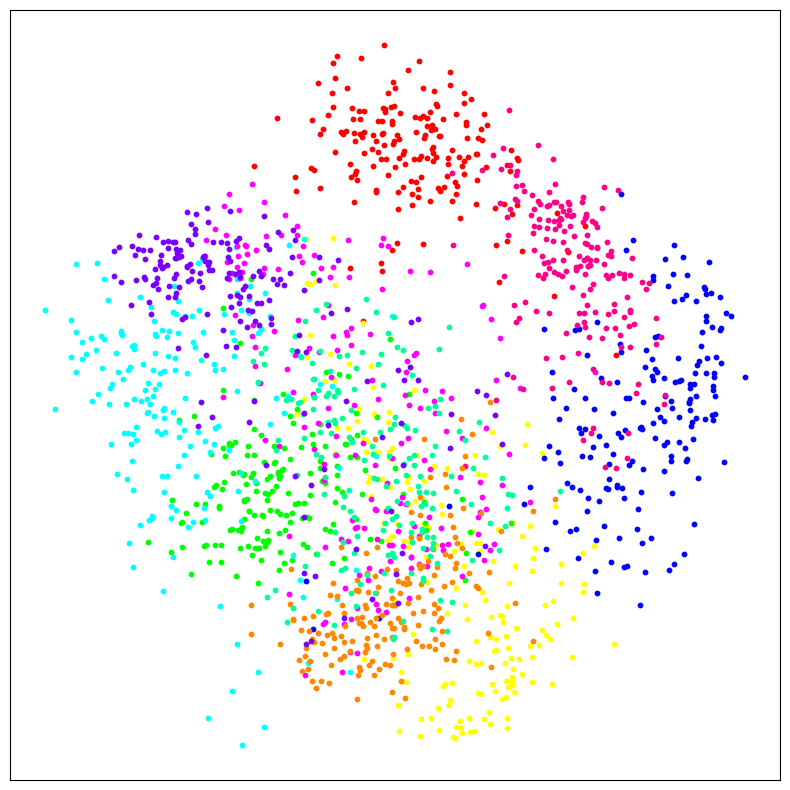

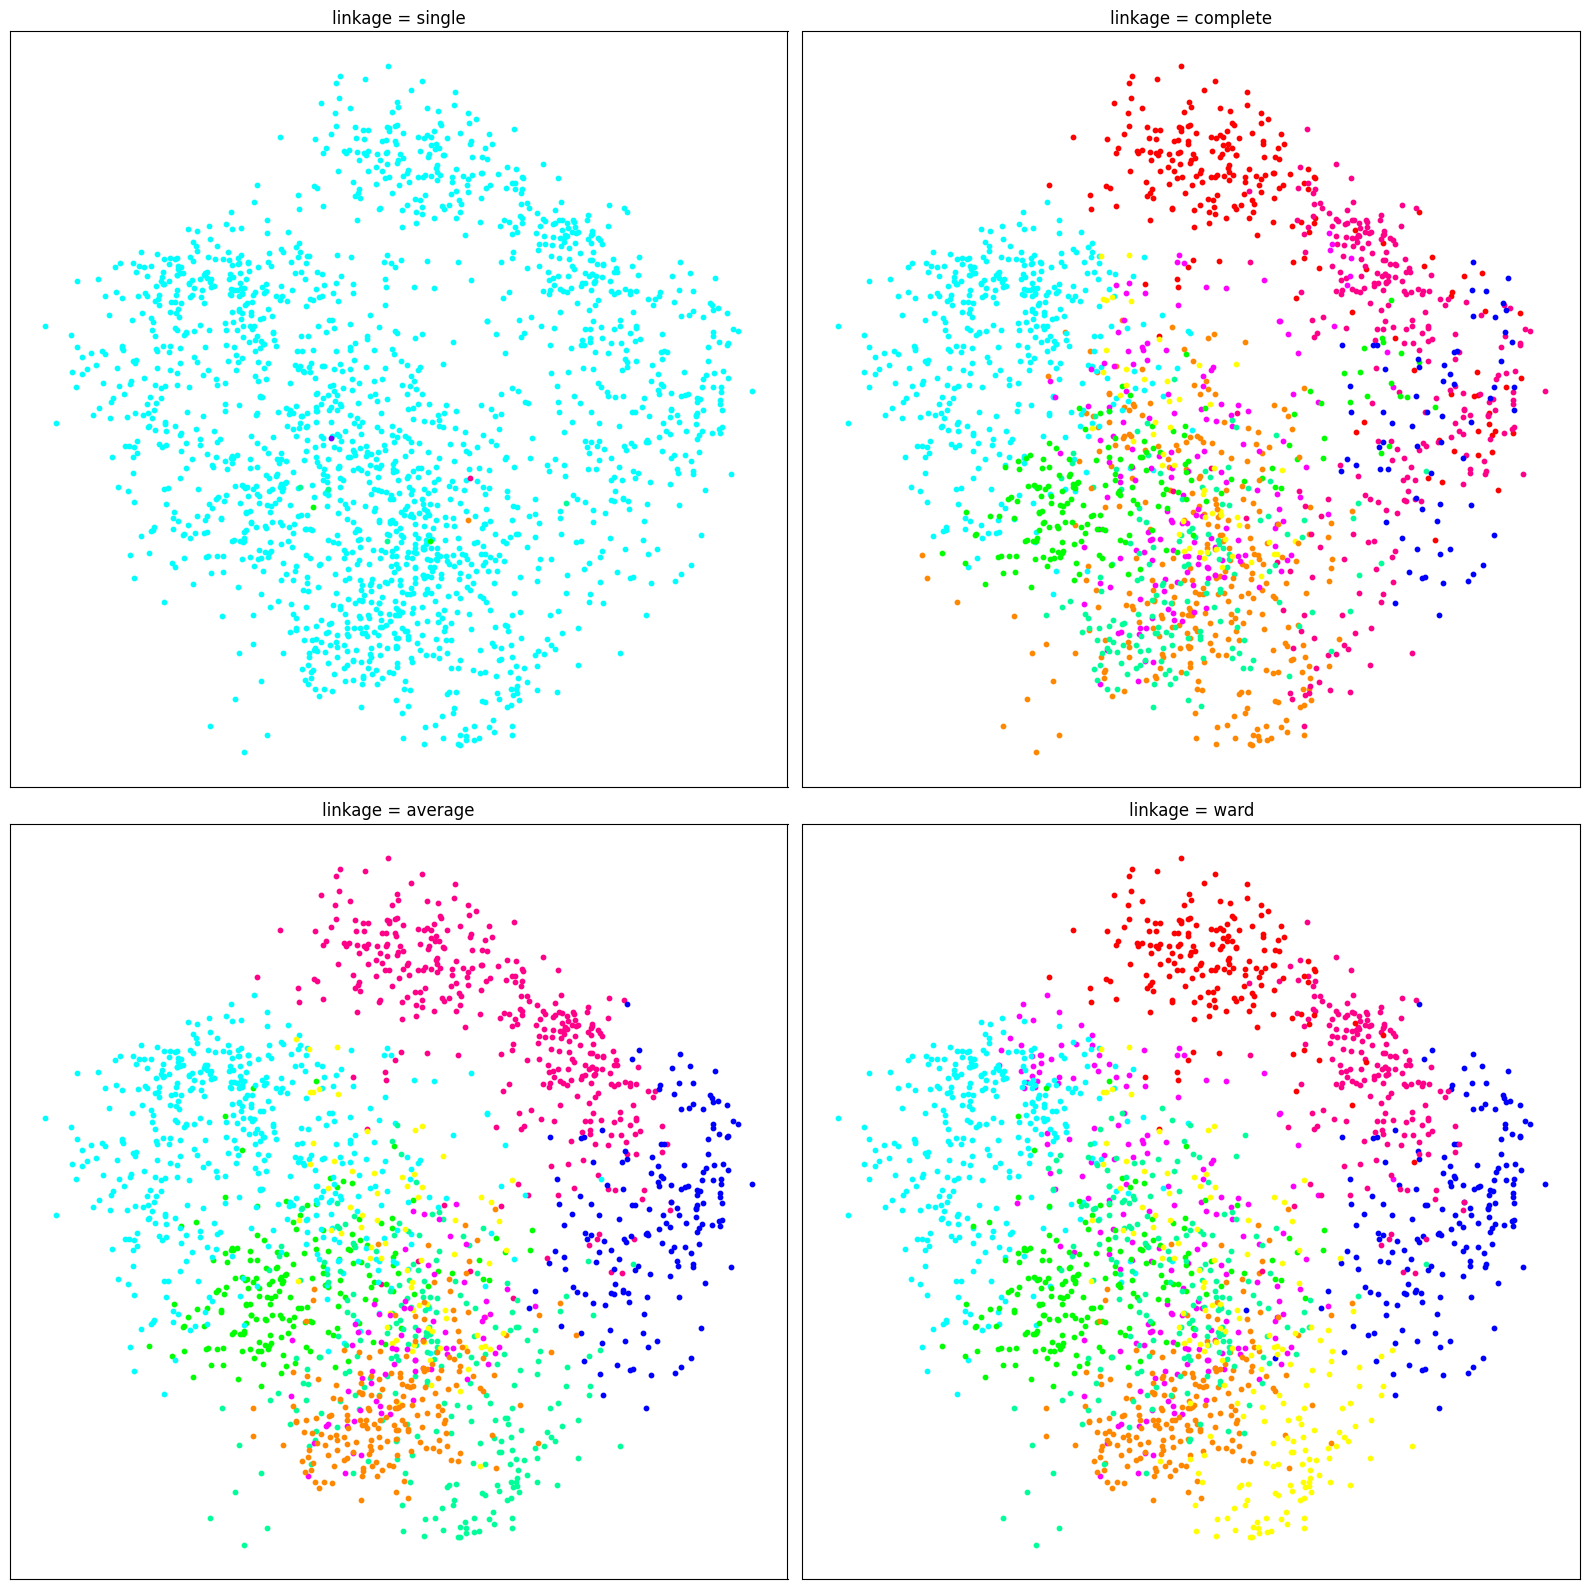

In [10]:
from sklearn.datasets import load_digits
# 1. 資料
digits = load_digits()
X = digits.data.astype("float32") / 16.0   # normalize
y = digits.target

agg = AgglomerativeClustering(n_clusters=10, linkage='average')
labels = agg.fit_predict(X)

# 2. PCA 降到 2 維
pca = PCA(n_components=2, random_state=0)
X_embedded = pca.fit_transform(X)

# 3. 四種 linkage
methods = ["single", "complete", "average", "ward"]
colors = ["#FF0000","#FFFF00","#00FF00","#00FFFF","#0000FF",
          "#FF00FF","#FF0088","#FF8800","#00FF99","#7700FF"]

plt.rcParams["figure.figsize"] = (8,8)
fig, ax = plt.subplots()

for d in range(10):
    mask = (y == d)
    ax.scatter(X_embedded[mask, 0],
               X_embedded[mask, 1],
               s=10,
               c=colors[d],
               label=str(d))

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

plt.rcParams["figure.figsize"] = (16,16)
fig, axes = plt.subplots(2, 2)

for ax, method in zip(axes.ravel(), methods):
    agg = AgglomerativeClustering(n_clusters=10, linkage=method)
    labels = agg.fit_predict(X)

    # 建立：cluster label -> 主要 digit 的對應
    label2digit = {}
    for c in range(10):
        mask = (labels == c)
        majority_digit = Counter(y[mask]).most_common(1)[0][0]
        label2digit[c] = majority_digit

    # 依照「對應的 digit 顏色」來畫每個 cluster
    for c in range(10):
        mask = (labels == c)
        digit_color = colors[label2digit[c]]   # digit 0~9 的固定顏色
        ax.scatter(X_embedded[mask, 0],
                   X_embedded[mask, 1],
                   c=digit_color,
                   s=10)

    ax.set_title(f"linkage = {method}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

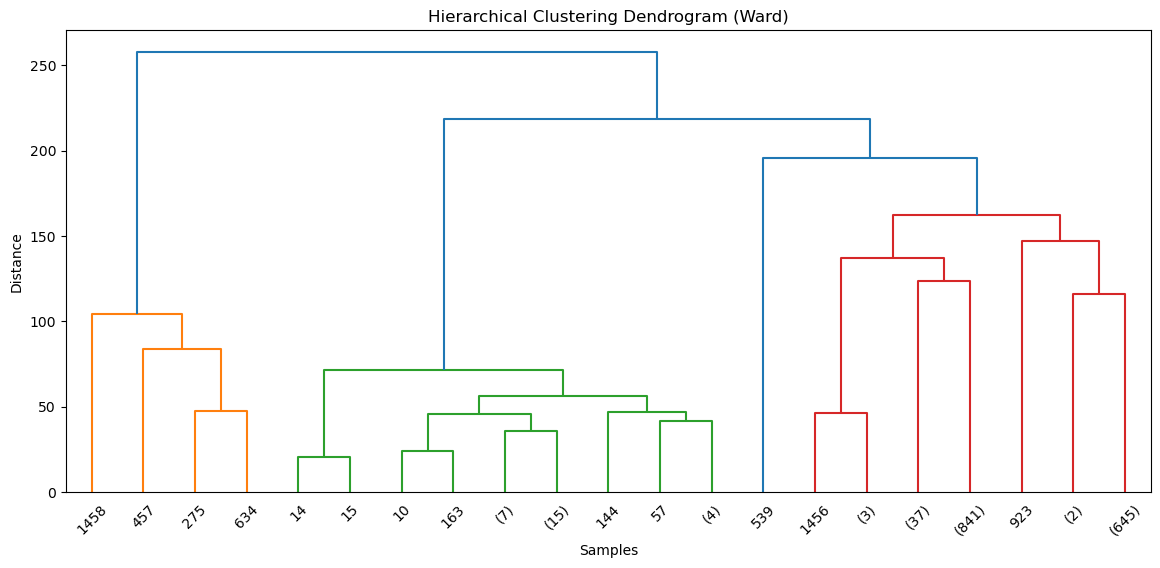

PCA 保留 131 個主成分


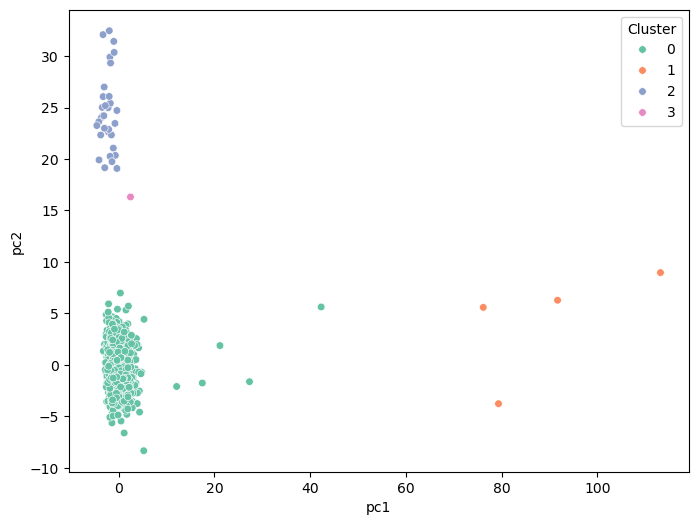

cluster     0  1   2  3
y                      
0        1434  3  25  1
1          96  1   7  0


In [21]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

# 用 Ward linkage 建 dendrogram（agglomerative 標準做法）
Z = linkage(X_std, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5)   # p=5 保留前幾層以免太大
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# 做實際分群（例如分成 4 群）
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = agg.fit_predict(X_std)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

In [ ]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))

---
---

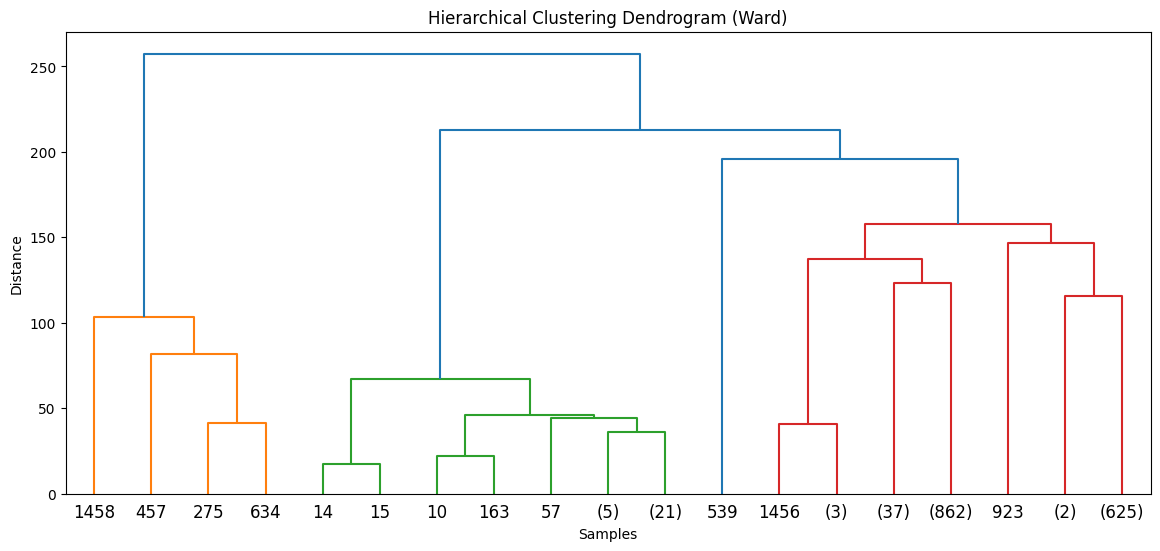

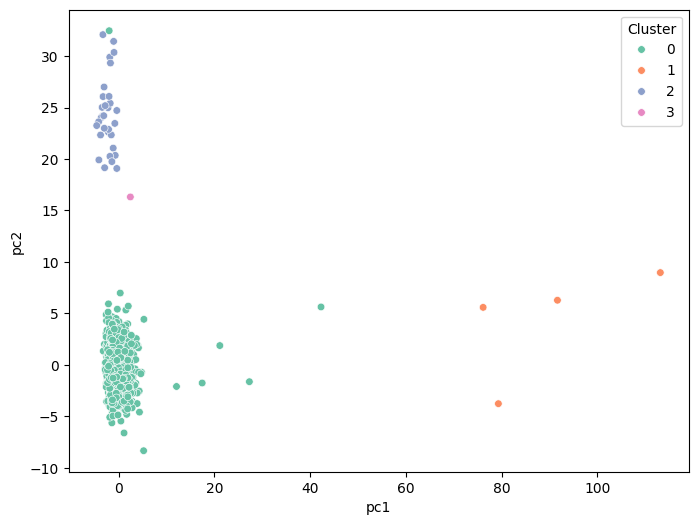

cluster     0  1   2  3
y                      
0        1435  3  24  1
1          96  1   7  0


In [4]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

# 用 Ward linkage 建 dendrogram（agglomerative 標準做法）
Z = linkage(X_pca, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5)   # p=5 保留前幾層以免太大
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# 做實際分群（例如分成 4 群）
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = agg.fit_predict(X_pca)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

In [8]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[256  32]
 [ 14   5]]

SVM(RBF) confusion matrix:
[[288   0]
 [ 19   0]]

DecisionTree confusion matrix:
[[266  22]
 [ 18   1]]

RandomForest confusion matrix:
[[288   0]
 [ 19   0]]

XGBoost confusion matrix:
[[288   0]
 [ 19   0]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8502  0.1111       0.2632       0.8889  0.4837
SVM(RBF)            0.9381  0.0000       0.0000       1.0000  0.0000
DecisionTree        0.8697  0.0764       0.0526       0.9236  0.2205
RandomForest        0.9381  0.0000       0.0000       1.0000  0.0000
XGBoost             0.9381  0.0000       0.0000       1.0000  0.0000


---
---

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

X_cos = pd.DataFrame(normalize(X_std, norm='l2'), columns=X.columns, index=X.index)

kmeans = KMeans(n_clusters=2, n_init=100, random_state=42)
labels = kmeans.fit_predict(X_cos)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

---
---

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

# 先用 k 距離找 eps（常見做法：取第 k 個近鄰距離的高分位數）
k = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(X_std)
dists, _ = nbrs.kneighbors(X_std)
k_dists = np.sort(dists[:, -1])             # 每點到第k鄰的距離
eps = np.percentile(k_dists, 90)            # 你也可改 85~95 做靈敏度分析

db = DBSCAN(eps=eps, min_samples=k, n_jobs=-1)
labels = db.fit_predict(X_std)              # -1 代表噪聲點

sizes = pd.Series(labels, name='cluster').value_counts().sort_index()
print('cluster sizes (含 -1=noise):', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'cluster': labels})
ct = pd.crosstab(df['y'], df['cluster'], rownames=['y'], colnames=['cluster'])
print(ct)